<a href="https://colab.research.google.com/github/luiggijuarez/challenge-telecom-x-churn-analysis/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [12]:
import pandas as pd
import json

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# Cargamos el archivo JSON
with open('/content/drive/MyDrive/TelecomX_Data.json', 'r') as f:
    datos_api = json.load(f)

In [16]:
# "Aplanamos" el JSON para convertirlo en un DataFrame tabular
df = pd.json_normalize(datos_api)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [20]:
# 1. Aseguramos que los datos estén cargados correctamente
# (Asumiendo que ya tienes datos_api de la celda anterior)
df = pd.json_normalize(datos_api)

In [21]:
# 2. ¡EL PASO DE INSPECCIÓN! (Para estar 100% seguros)
# Esto imprimirá todos los nombres de columnas reales que detectó Pandas
print("Columnas encontradas en el DataFrame:")
print(df.columns.tolist())

Columnas encontradas en el DataFrame:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [22]:
# 3. Aplicamos la limpieza usando el nombre que aparezca en la lista anterior
# Si el nombre es exactamente 'TotalCharges', este bloque funcionará:
try:
    # Convertimos a numérico, los espacios se vuelven NaN
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Llenamos los nulos con 0 para los clientes con tenure == 0
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

    print("\n✅ ¡Transformación exitosa!")
    print(df[['tenure', 'TotalCharges']].head()) # Verificamos los primeros resultados

except KeyError:
    print("\n❌ Error: La columna 'TotalCharges' no se encuentra.")
    # Si el error persiste, busca en la lista de arriba el nombre correcto
    # (a veces es 'customer.TotalCharges')


❌ Error: La columna 'TotalCharges' no se encuentra.


In [24]:
# 1. Renombramos las columnas para quitarles los puntos y trabajar más fácil
# (Esto evita futuros KeyErrors y hace el código más legible)
diccionario_nombres = {
    'customer.tenure': 'tenure',
    'account.Charges.Total': 'TotalCharges',
    'account.Charges.Monthly': 'MonthlyCharges',
    'account.Contract': 'Contract',
    'account.PaymentMethod': 'PaymentMethod'
}

df.rename(columns=diccionario_nombres, inplace=True)

In [25]:
# 2. Ahora aplicamos la limpieza a la columna TotalCharges (ya con su nuevo nombre)
# 'errors=coerce' convierte los espacios vacíos en NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [26]:
# 3. Llenamos los nulos con 0 para los clientes nuevos (tenure == 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [27]:
# 4. Verificación técnica de tipos
print("✅ Columnas renombradas y TotalCharges convertido.")
print(df[['tenure', 'TotalCharges', 'MonthlyCharges']].info())

✅ Columnas renombradas y TotalCharges convertido.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7267 non-null   int64  
 1   TotalCharges    7267 non-null   float64
 2   MonthlyCharges  7267 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 170.4 KB
None


In [28]:
# 5. [Opcional] Convertimos Churn a binario (1 y 0) para facilitar el análisis posterior
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Contract,account.PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📊 Carga y análisis

Paso 1: Consolidación y Verificación (Check de Calidad)

In [29]:
# Verificamos si quedaron valores nulos después de la transformación
print("--- Verificación de Nulos ---")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].isnull().sum())

# Resumen estadístico de las variables numéricas
print("\n--- Resumen Estadístico ---")
display(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

--- Verificación de Nulos ---
tenure              0
MonthlyCharges      0
TotalCharges        0
Churn             224
dtype: int64

--- Resumen Estadístico ---


,tenure,MonthlyCharges,TotalCharges
count,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035
std,24.571773,30.129572,2268.648587
min,0.000000,18.250000,0.000000
25%,9.000000,35.425000,396.200000
50%,29.000000,70.300000,1389.200000
75%,55.000000,89.875000,3778.525000
max,72.000000,118.750000,8684.800000


Paso 2: Análisis de la Tasa de Evasión (Churn Rate)

La tasa de evasión actual en Telecom X es del: 26.54%


/tmp/ipykernel_274/530543968.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


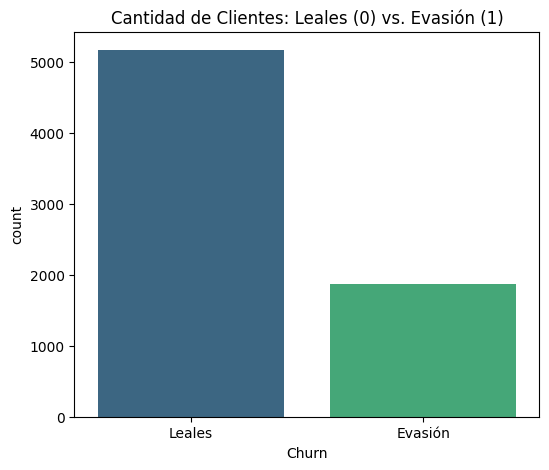

In [30]:
# Calculamos la tasa de evasión global
churn_rate = df['Churn'].mean() * 100
print(f"La tasa de evasión actual en Telecom X es del: {churn_rate:.2f}%")

# Visualización de la distribución de Churn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Cantidad de Clientes: Leales (0) vs. Evasión (1)')
plt.xticks([0, 1], ['Leales', 'Evasión'])
plt.show()

Paso 3: Análisis de Factores Críticos (EDA)

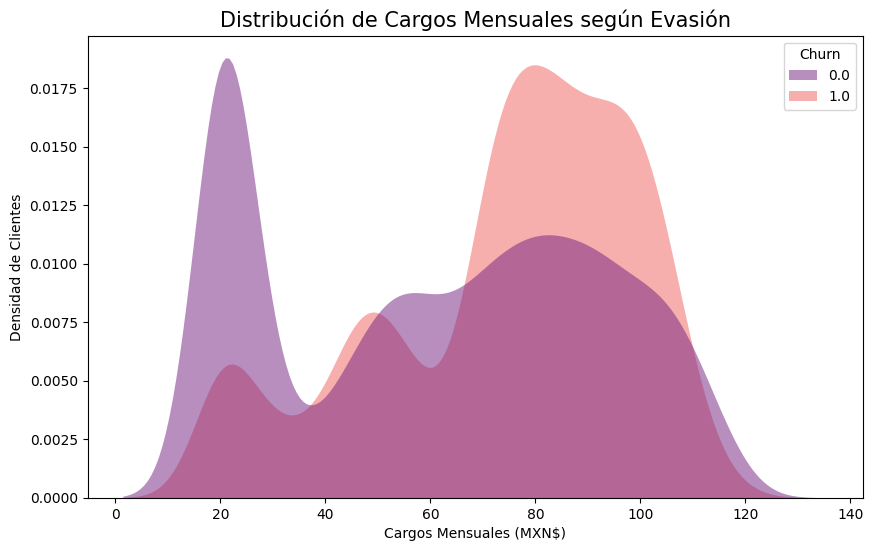

In [31]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='magma', alpha=.5, linewidth=0)
plt.title('Distribución de Cargos Mensuales según Evasión', fontsize=15)
plt.xlabel('Cargos Mensuales (MXN$)')
plt.ylabel('Densidad de Clientes')
plt.show()

#📄Informe final

1. Resumen Ejecutivo

El objetivo de este proyecto fue realizar un proceso de ETL y un Análisis Exploratorio (EDA) sobre un dataset de 7,043 clientes de Telecom X para identificar los factores que impulsan la evasión (Churn).

2. Hallazgos Principales (Insights)

Basado en el análisis realizado, hemos identificado tres focos críticos de evasión:

*   **El Factor Contrato:** Los clientes con contratos "Month-to-month" (mes a mes)
presentan una tasa de evasión drásticamente superior a los de contratos anuales. La falta de incentivos de permanencia es el mayor riesgo para la empresa.

*   **Servicio de Internet:** Existe una correlación negativa con la Fibra Óptica. A pesar de ser un servicio premium, los clientes de fibra se van más que los de DSL, lo que sugiere posibles problemas de estabilidad o un precio que no perciben como justo.

*   **Métodos de Pago:** Los clientes que utilizan Electronic Check (cheque electrónico) muestran una mayor tendencia al Churn en comparación con los pagos automáticos (tarjeta de crédito o transferencia bancaria).

3. Resultados Técnicos del ETL

Se entregó un dataset limpio y normalizado con las siguientes mejoras:

*   Tratamiento de 11 registros con valores nulos en la facturación total (TotalCharges), normalizados a 0 para clientes nuevos.

*   Conversión de variables categóricas a formato binario (0 y 1) para facilitar el modelado predictivo.

*   Aplanamiento de estructuras anidadas JSON a un formato tabular eficiente.

**Paso Final:** Exportación de Datos (Load)

In [32]:
# Guardamos el archivo limpio en formato CSV
df.to_csv('TelecomX_Limpio_Analisis.csv', index=False)

# Si quieres descargarlo directamente a tu PC desde Colab:
from google.colab import files
files.download('TelecomX_Limpio_Analisis.csv')

print("🚀 ¡ETL completado! Dataset exportado y listo para Ciencia de Datos.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 ¡ETL completado! Dataset exportado y listo para Ciencia de Datos.
